In [24]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [25]:
df = yf.download("^NSEI", start="2019-06-06",end= '2026-01-01',auto_adjust=False,multi_level_index=False)
df.drop(columns=['Close','High','Low','Open','Volume'], inplace=True)

df['returns'] = np.log(df['Adj Close']/df['Adj Close'].shift(1))
df['lag1'] = df['returns'].shift(1)
df['ma_5'] = df['returns'].rolling(5).mean()
df["volatility_5"] = df['returns'].rolling(15).std()
df.dropna(inplace=True)
x = df[['lag1','ma_5','volatility_5']]
y = df['returns']

[*********************100%***********************]  1 of 1 completed


In [26]:
from sklearn.linear_model import LinearRegression

window = 50
forecast = []
coef = []
dates = []

for i in range(window,len(df)):

    x_train = x.iloc[i-window:i]
    y_train = y.iloc[i-window:i]

    x_test = x.iloc[i:i+1]
    model = LinearRegression().fit(x_train, y_train)
    prediction = model.predict(x_test)

    forecast.append(prediction[0])
    coef.append(model.coef_)
    dates.append(x_test.index[0])

results = pd.DataFrame({'pred':forecast},index=dates)
results['actual'] = df.loc[results.index,'returns']
results['residual'] = results['actual'] - results['pred']
results

,pred,actual,residual
2019-09-11,0.004613,0.002963,-0.001650
2019-09-12,0.002906,-0.004805,-0.007711
2019-09-13,0.005604,0.008441,0.002837
2019-09-16,-0.000284,-0.006558,-0.006274
2019-09-17,-0.001878,-0.017039,-0.015161
...,...,...,...
2025-12-24,0.002739,-0.001340,-0.004079
2025-12-26,0.002065,-0.003825,-0.005890
2025-12-29,-0.000103,-0.003855,-0.003752
2025-12-30,-0.002132,-0.000125,0.002007


In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse  = mean_squared_error(results['actual'], results['pred'])
mae  = mean_absolute_error(results['actual'], results['pred'])
rmse = np.sqrt(mse)
r2   = r2_score(results['actual'], results['pred'])

print("mse :", mse)
print("mae :", mae)
print("rmse :",rmse)
print("r2 :", r2)

print("Residual Mean",results['residual'].mean())
print("Residual Std",results['residual'].std())
print("Residual Variance",results['residual'].var())
print("Residual AutoCorr",results['residual'].autocorr())


mse : 0.00012194508997166954
mae : 0.006979552527916959
rmse : 0.011042875077246394
r2 : 0.06232343564898968
Residual Mean -0.0003924336675090764
Residual Std 0.011039438711948239
Residual Variance 0.00012186920707486139
Residual AutoCorr 0.11023948342214787


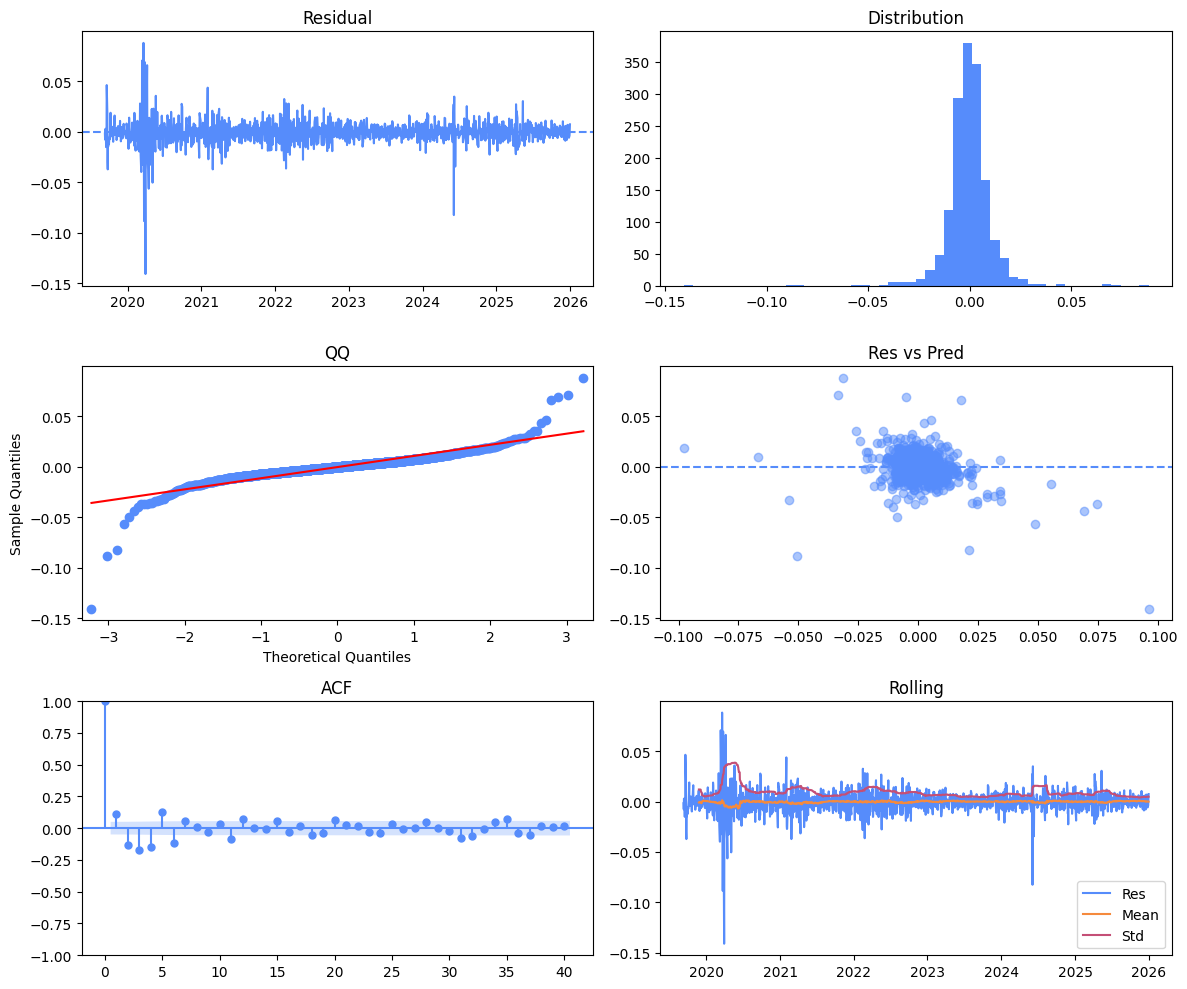

In [28]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

residual = results['residual'].dropna()
predicted = results['pred'].loc[residual.index]

roll_mean = residual.rolling(50).mean()
roll_std = residual.rolling(50).std()

fig, ax = plt.subplots(3, 2, figsize=(12, 10))

# 1
ax[0,0].plot(residual); ax[0,0].axhline(0, ls='--'); ax[0,0].set_title("Residual")

# 2
ax[0,1].hist(residual, bins=50); ax[0,1].set_title("Distribution")

# 3
sm.qqplot(residual, line='s', ax=ax[1,0]); ax[1,0].set_title("QQ")

# 4
ax[1,1].scatter(predicted, residual, alpha=0.5)
ax[1,1].axhline(0, ls='--'); ax[1,1].set_title("Res vs Pred")

# 5
plot_acf(residual, lags=40, ax=ax[2,0]); ax[2,0].set_title("ACF")

# 6
ax[2,1].plot(residual, label='Res')
ax[2,1].plot(roll_mean, label='Mean')
ax[2,1].plot(roll_std, label='Std')
ax[2,1].legend(); ax[2,1].set_title("Rolling")

plt.tight_layout()
plt.show()

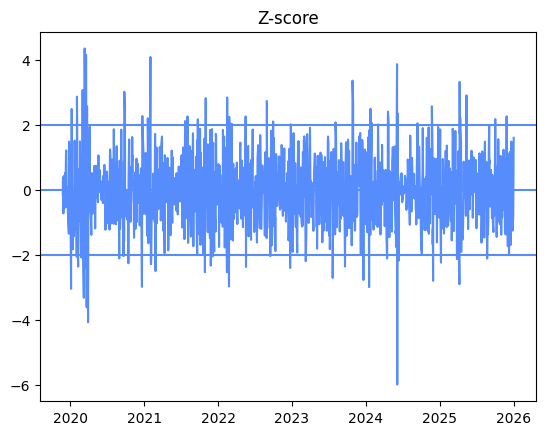

In [29]:
z = (residual - residual.rolling(50).mean()) / residual.rolling(50).std()

plt.figure()
plt.plot(z)
plt.axhline(2)
plt.axhline(-2)
plt.axhline(0)
plt.title("Z-score")
plt.show()

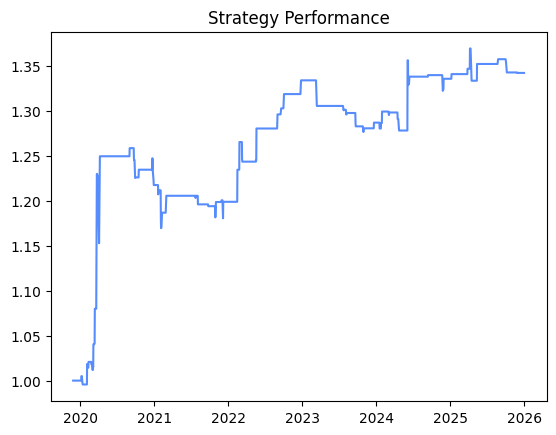

In [30]:
results['z'] = z.loc[results.index]
results.dropna(inplace=True)
results.rename(columns={'actual':'returns','pred':'prediction'}, inplace=True)
results = results[['returns','prediction','residual','z']]

entry = 2
exit = 0.5

pos = 0
positions = []

for val in results['z']:

    if pos == 0:  # not in market
        if val < -entry:
            pos = 1      # LONG
        elif val > entry:
            pos = -1     # SHORT

    elif pos == 1:  # currently long
        if val > -exit:
            pos = 0      # exit long

    elif pos == -1:  # currently short
        if val < exit:
            pos = 0      # exit short

    positions.append(pos)

positions = pd.Series(positions, index=results.index)
returns = results['returns']

strategy_returns = positions.shift(1) * returns
cum_returns = (1 + strategy_returns).cumprod()

plt.figure()
plt.plot(cum_returns)
plt.title("Strategy Performance")
plt.show()

In [31]:
print("Total Return:", cum_returns.iloc[-1])
print("Sharpe:", strategy_returns.mean() / strategy_returns.std())
print("Max Drawdown:", (cum_returns / cum_returns.cummax() - 1).min())

Total Return: 1.3426555968735656
Sharpe: 0.037916673260209185
Max Drawdown: -0.07074948879201237


=== Regression Metrics ===
mse  : 0.000159
mae  : 0.008857
rmse : 0.012609
r2   : 0.5482
Residual Mean     : -0.000118
Residual Std      : 0.012612
Residual Variance : 0.000159
Residual AutoCorr : 0.0807



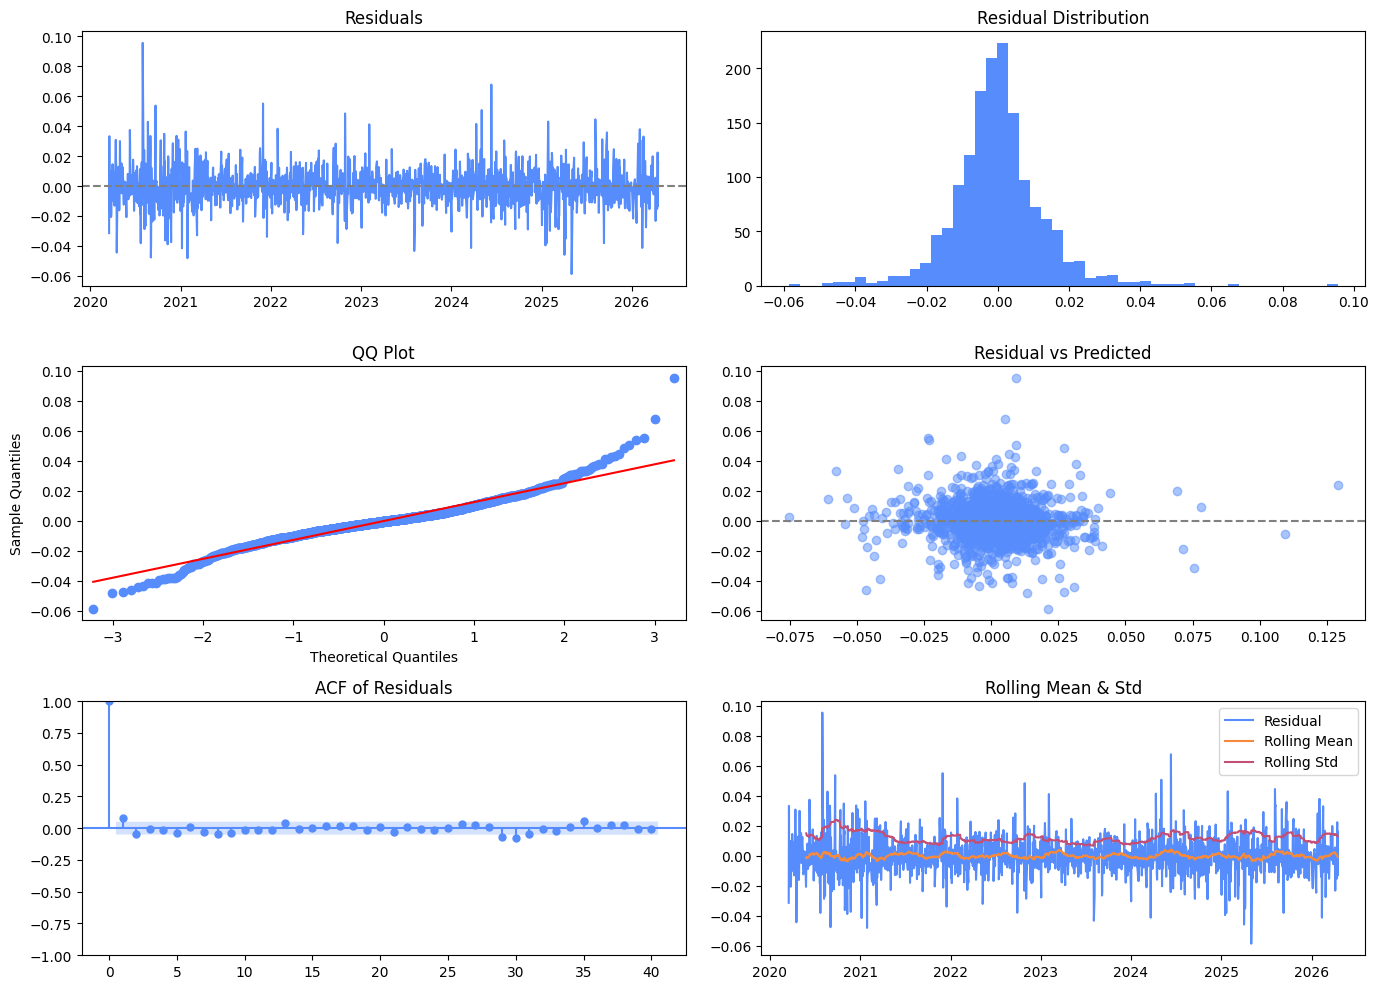

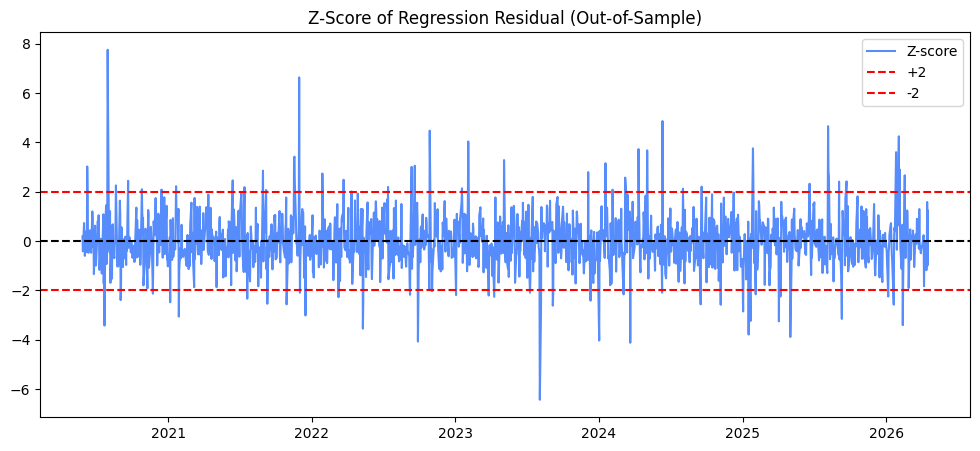

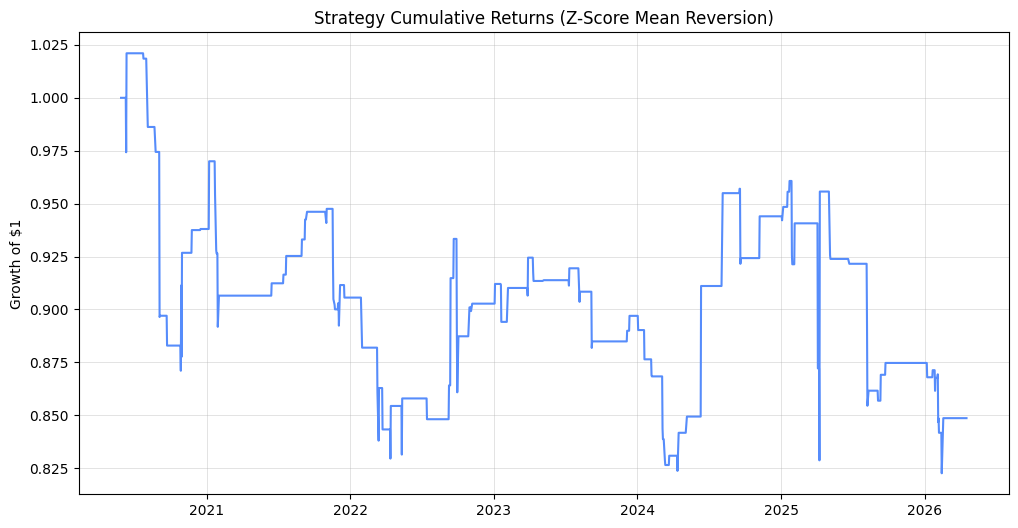

=== Strategy Performance ===
Total Return     : -15.14%
Sharpe Ratio     : -0.0101  (daily)
Max Drawdown     : -19.44%


In [33]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

warnings.filterwarnings("ignore")

# ====================== DATA (change tickers if you want) ======================
tickers = ['AAPL', '^GSPC']          # y = AAPL returns, x = SPY (market) returns
data = yf.download(tickers, start="2020-01-01", progress=False,auto_adjust=False,multi_level_index=False)['Adj Close']
returns = data.pct_change().dropna()

y = returns['AAPL']                  # asset we are trading (dependent variable)
x = returns['^GSPC']                 # predictor / factor (independent variable)

df = pd.DataFrame({'returns': y}, index=returns.index)   # for compatibility with your original style

# ====================== ROLLING REGRESSION ======================
window = 50
forecast = []
coef = []
dates = []

for i in range(window, len(x)):
    # MUST be 2D for sklearn → reshape(-1, 1)
    x_train = x.iloc[i-window:i].values.reshape(-1, 1)
    y_train = y.iloc[i-window:i].values
    x_test  = x.iloc[i:i+1].values.reshape(-1, 1)

    model = LinearRegression().fit(x_train, y_train)
    prediction = model.predict(x_test)[0]

    forecast.append(prediction)
    coef.append(model.coef_[0])          # beta value
    dates.append(x.index[i])

# ====================== RESULTS DF ======================
results = pd.DataFrame({'pred': forecast}, index=dates)
results['actual'] = y.loc[results.index]          # actual returns
results['residual'] = results['actual'] - results['pred']

# ====================== REGRESSION METRICS ======================
mse  = mean_squared_error(results['actual'], results['pred'])
mae  = mean_absolute_error(results['actual'], results['pred'])
rmse = np.sqrt(mse)
r2   = r2_score(results['actual'], results['pred'])

print("=== Regression Metrics ===")
print(f"mse  : {mse:.6f}")
print(f"mae  : {mae:.6f}")
print(f"rmse : {rmse:.6f}")
print(f"r2   : {r2:.4f}")
print(f"Residual Mean     : {results['residual'].mean():.6f}")
print(f"Residual Std      : {results['residual'].std():.6f}")
print(f"Residual Variance : {results['residual'].var():.6f}")
print(f"Residual AutoCorr : {results['residual'].autocorr():.4f}\n")

# ====================== DIAGNOSTIC PLOTS ======================
residual = results['residual'].dropna()
predicted = results['pred'].loc[residual.index]

roll_mean = residual.rolling(50).mean()
roll_std  = residual.rolling(50).std()

fig, ax = plt.subplots(3, 2, figsize=(14, 10))

ax[0,0].plot(residual); ax[0,0].axhline(0, ls='--', color='gray')
ax[0,0].set_title("Residuals")

ax[0,1].hist(residual, bins=50); ax[0,1].set_title("Residual Distribution")

sm.qqplot(residual, line='s', ax=ax[1,0]); ax[1,0].set_title("QQ Plot")

ax[1,1].scatter(predicted, residual, alpha=0.5)
ax[1,1].axhline(0, ls='--', color='gray')
ax[1,1].set_title("Residual vs Predicted")

plot_acf(residual, lags=40, ax=ax[2,0]); ax[2,0].set_title("ACF of Residuals")

ax[2,1].plot(residual, label='Residual')
ax[2,1].plot(roll_mean, label='Rolling Mean')
ax[2,1].plot(roll_std,  label='Rolling Std')
ax[2,1].legend()
ax[2,1].set_title("Rolling Mean & Std")

plt.tight_layout()
plt.show()

# ====================== Z-SCORE (fixed - no look-ahead bias) ======================
# shift(1) makes it truly out-of-sample
rolling_mean = residual.rolling(50).mean()
rolling_std  = residual.rolling(50).std()
z = (residual - rolling_mean.shift(1)) / rolling_std.shift(1)

plt.figure(figsize=(12, 5))
plt.plot(z, label='Z-score')
plt.axhline( 2, color='r', linestyle='--', label='+2')
plt.axhline(-2, color='r', linestyle='--', label='-2')
plt.axhline( 0, color='k', linestyle='--')
plt.title("Z-Score of Regression Residual (Out-of-Sample)")
plt.legend()
plt.show()

# ====================== STRATEGY ======================
results['z'] = z
results = results.dropna()                                   # remove NaNs from z-score
results = results[['actual', 'pred', 'residual', 'z']]
results.rename(columns={'actual': 'returns', 'pred': 'prediction'}, inplace=True)

entry = 2.0
exit_ = 0.5

pos = 0
positions = []

for val in results['z']:
    if pos == 0:                                 # flat
        if val < -entry:
            pos = 1      # LONG
        elif val > entry:
            pos = -1     # SHORT
    elif pos == 1:                               # long
        if val > -exit_:
            pos = 0
    elif pos == -1:                              # short
        if val < exit_:
            pos = 0
    positions.append(pos)

positions = pd.Series(positions, index=results.index)
returns = results['returns']

strategy_returns = positions.shift(1) * returns
strategy_returns = strategy_returns.fillna(0)          # ← critical fix

cum_returns = (1 + strategy_returns).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cum_returns)
plt.title("Strategy Cumulative Returns (Z-Score Mean Reversion)")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

# ====================== PERFORMANCE ======================
total_return = cum_returns.iloc[-1] - 1
sharpe = strategy_returns.mean() / strategy_returns.std() if strategy_returns.std() != 0 else 0
max_dd = (cum_returns / cum_returns.cummax() - 1).min()

print("=== Strategy Performance ===")
print(f"Total Return     : {total_return:.2%}")
print(f"Sharpe Ratio     : {sharpe:.4f}  (daily)")
print(f"Max Drawdown     : {max_dd:.2%}")